In [1]:
#!/usr/bin/python3

# @Time     : 22/5/24
# @Author   : Noujoud Nader
# @FileName : main.py
import torch
import pandas as pd

from models.trainer import load_from_checkpoint, model_train, model_test
from torch_geometric.loader import DataLoader
from loader.dataloader_hurricane import *


/Users/noujoudnader/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/torch_geometric/typing.py:18: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/noujoudnader/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/libpyg.so, 0x0006): Symbol not found: __ZN2at4_ops10cumsum_out4callERKNS_6TensorExN3c108optionalINS5_10ScalarTypeEEERS2_
  Referenced from: /Users/noujoudnader/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/libpyg.so
  Expected in: /Users/noujoudnader/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
2024-08-21 13:03:14.848827: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild Tensor

In [2]:
torch.__version__

'2.2.2'

In [4]:
%load_ext autoreload
%autoreload 2
%run -i loader/dataloader_hurricane.py


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
%reload_ext autoreload

In [3]:
from loader.dataloader_hurricane import *

data_df=pd.read_csv("/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/stgat_traffic_prediction-main/Correlations/Ian_hydro.csv",low_memory=False).dropna()
data_df

,time_UTC,observed_data,forecast_data,offset,x,y,station_id,agency,storm,year,time_UTC_dt
0,2022-09-25 01:00:00,2.560,2.315,-0.245,-73.710194,40.866222,1302250,USGS,IAN,2022,60.0
1,2022-09-25 02:00:00,2.540,3.625,1.085,-73.710194,40.866222,1302250,USGS,IAN,2022,120.0
2,2022-09-25 03:00:00,2.940,3.959,1.019,-73.710194,40.866222,1302250,USGS,IAN,2022,180.0
3,2022-09-25 04:00:00,3.270,3.747,0.477,-73.710194,40.866222,1302250,USGS,IAN,2022,240.0
4,2022-09-25 05:00:00,2.970,2.483,-0.487,-73.710194,40.866222,1302250,USGS,IAN,2022,300.0
...,...,...,...,...,...,...,...,...,...,...,...
41759,2022-10-01 19:00:00,1.060,0.452,-0.608,-67.938500,18.089910,9759938,NOAA_NOS,IAN,2022,9780.0
41760,2022-10-01 20:00:00,1.063,0.410,-0.653,-67.938500,18.089910,9759938,NOAA_NOS,IAN,2022,9840.0
41761,2022-10-01 21:00:00,1.024,0.360,-0.664,-67.938500,18.089910,9759938,NOAA_NOS,IAN,2022,9900.0
41762,2022-10-01 22:00:00,0.981,0.293,-0.688,-67.938500,18.089910,9759938,NOAA_NOS,IAN,2022,9960.0


In [4]:
Ids=data_df['station_id'].unique()   
station_df=create_stationDf(data_df,Ids, 'offset')


/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/Spatio_Temporal/loader/dataloader_hurricane.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_station[id]=sequence
/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/Spatio_Temporal/loader/dataloader_hurricane.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_station[id]=sequence
/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurr

,1302250,1304200,1304746,1306402,1309225,1310521,1311145,1376269,1376562,1484085,...,8775296,8779280,9751364,9751381,9751401,9751639,9752235,9759110,9759394,9759938
0,-0.245,0.079,0.009,-0.375,-0.484,0.008,-0.340,-0.435,-0.425,-0.319,...,-0.646,-1.013,-0.602,-0.543,-0.725,-0.521,-0.438,-0.551,-0.598,-0.343
1,1.085,0.164,0.237,-0.464,-0.430,0.331,-0.144,-0.315,-0.309,-0.411,...,-0.629,-0.991,-0.623,-0.557,-0.786,-0.471,-0.447,-0.588,-0.536,-0.338
2,1.019,0.347,0.527,-0.421,-0.207,0.429,-0.151,-0.058,-0.214,-0.525,...,-0.605,-0.973,-0.633,-0.492,-0.751,-0.446,-0.388,-0.588,-0.536,-0.378
3,0.477,0.400,0.756,-0.350,0.029,0.520,-0.102,0.193,-0.186,-0.667,...,-0.596,-0.936,-0.596,-0.497,-0.738,-0.480,-0.421,-0.618,-0.462,-0.380
4,-0.487,0.398,0.883,-0.268,0.170,0.633,-0.063,0.574,-0.112,-0.706,...,-0.590,-0.922,-0.545,-0.428,-0.682,-0.386,-0.365,-0.470,-0.355,-0.424
5,-2.408,0.423,0.890,-0.168,0.255,0.672,0.048,0.704,0.032,-0.700,...,-0.551,-0.930,-0.578,-0.406,-0.617,-0.340,-0.266,-0.490,-0.242,-0.388
6,-4.451,0.489,0.688,-0.047,0.317,0.653,0.624,0.852,0.493,-0.554,...,-0.559,-0.920,-0.596,-0.321,-0.564,-0.320,-0.284,-0.576,-0.140,-0.450
7,-5.844,0.582,0.321,0.050,0.455,-0.025,0.829,0.909,1.076,-0.195,...,-0.585,-0.933,-0.614,-0.310,-0.528,-0.268,-0.231,-0.456,-0.205,-0.414
8,-6.470,0.271,0.027,0.177,0.549,-0.676,0.725,1.105,1.013,0.158,...,-0.614,-0.925,-0.584,-0.273,-0.469,-0.209,-0.165,-0.435,-0.380,-0.175
9,-6.628,0.160,-0.238,0.336,0.602,-0.837,0.519,1.195,0.454,0.412,...,-0.629,-0.918,-0.621,-0.289,-0.469,-0.265,-0.244,-0.415,-0.350,-0.145


In [ ]:
station_df.head(10)

In [ ]:
station_df.shape

In [ ]:
# data=np.array(station_df.iloc[0:21,:].values)
# print(data.shape)
# full_window = np.swapaxes(data, 0, 1) #data is the offset of station
# scaler = RobustScaler() # Create a scaler object
# full_window = scaler.fit_transform(full_window)    # Fit and transform the data
# # full_window = torch.tensor(scaled_data_x_np) 
# input=full_window[:, 0:config['N_HIST']] #input first n past points
# input

In [ ]:
# n_window = config['N_PRED'] + config['N_HIST'] # full window taken per time t

# for i in range(len(station_df)):
#             # (F,N) switched to (N,F)
#             sta=i
#             end = sta + n_window
            
#             if end > len(station_df)-1:
#                 break
#             # [21, 228]
#             data=np.array(station_df.iloc[sta:end,:].values)
#             print(data)

#             full_window = np.swapaxes(data, 0, 1) #data is the offset of station
#             input=full_window[:, 0:config['N_HIST']] #input first n past points
#             print(f"*******input{i}********")
#             print(input)
#             output=full_window[:, config['N_HIST']::] #output predicted after n points
#             print(f"******output{i}*********")
#             print(output)



In [5]:
from loader.dataloader_hurricane import *

# Constant config to use througout
config = {
    'BATCH_SIZE': 10,
    'EPOCHS': 100,
    'WEIGHT_DECAY': 5e-5,
    'INITIAL_LR': 3e-4,
    'CHECKPOINT_DIR': './runs',
    'N_PRED': 9,
    'N_HIST': 12,
    'DROPOUT': 0.2,
    # number of possible 5 minute measurements per day
    # number of days worth of data in the dataset
    # If false, use GCN paper weight matrix, if true, use GAT paper weight matrix
    'USE_GAT_WEIGHTS': True,
    'N_NODE': 204,
}
# Number of possible windows in a day
# config['N_SLOT']= config['N_DAY_SLOT'] - (config['N_PRED']+config['N_HIST']) + 1

data=prepare_gnn_data(data_df, config, W_mask=1000, Corr_mask=0.7)

/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/Spatio_Temporal/loader/dataloader_hurricane.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_station[id]=sequence
/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurricanes/Spatio_Temporal/loader/dataloader_hurricane.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_station[id]=sequence
/Users/noujoudnader/Library/CloudStorage/OneDrive-LouisianaStateUniversity/CCT RESEARCH/Hurr

In [6]:
train, val, test = get_splits_hurricanes(data, (0.7, 0.2, 0.1))

In [7]:
from torch_geometric.loader import DataLoader

train_dataloader = DataLoader(train, batch_size=config['BATCH_SIZE'], shuffle=True)
val_dataloader = DataLoader(val, batch_size=config['BATCH_SIZE'], shuffle=True)
test_dataloader = DataLoader(test, batch_size=config['BATCH_SIZE'], shuffle=False)

In [8]:
train_dataloader.dataset

[Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[204, 9]),
 Data(edge_index=[2, 3978], edge_attr=[3978], x=[204, 12], y=[20

In [9]:
from models.trainer import load_from_checkpoint, model_train, model_test
from torch_geometric.loader import DataLoader


 # Get gpu if you can
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

# Configure and train model
config['N_NODE'] = data[0].x.shape[0]
model = model_train(train_dataloader, val_dataloader, config, device)

Using cpu


Epoch 0: 100%|██████████| 11/11 [00:03<00:00,  2.87it/s]


Loss: 0.108
Train, MAE: 0.33690646290779114, RMSE: 0.37044277787208557
Valid, MAE: 0.3489784896373749, RMSE: 0.3801155984401703


Epoch 1: 100%|██████████| 11/11 [00:02<00:00,  3.67it/s]


Loss: 0.141


...

Epoch 35: 100%|██████████| 11/11 [00:01<00:00, 10.42it/s]


Loss: 0.020
Train, MAE: 0.10300736129283905, RMSE: 0.12265525013208389
Valid, MAE: 0.10290738940238953, RMSE: 0.12580297887325287


Epoch 36: 100%|██████████| 11/11 [00:00<00:00, 11.40it/s]


Loss: 0.017


Epoch 37:  18%|█▊        | 2/11 [00:00<00:00,  9.73it/s]

Test, MAE: 0.07952163368463516, RMSE: 0.10148387402296066
Pred: torch.Size([2, 2040, 9])
Truth: torch.Size([2, 2040, 9])
shape: 2040
shape after: torch.Size([2, 10, 204, 9])
tensor([[[0.4874, 0.5442, 0.6483, 0.6230, 0.5054, 0.4310, 0.3423, 0.3095,
          0.2628],
         [0.5442, 0.6483, 0.6230, 0.5054, 0.4310, 0.3423, 0.3095, 0.2628,
          0.2367],
         [0.6483, 0.6230, 0.5054, 0.4310, 0.3423, 0.3095, 0.2628, 0.2367,
          0.2359],
         [0.6230, 0.5054, 0.4310, 0.3423, 0.3095, 0.2628, 0.2367, 0.2359,
          0.3386],
         [0.5054, 0.4310, 0.3423, 0.3095, 0.2628, 0.2367, 0.2359, 0.3386,
          0.4334],
         [0.4310, 0.3423, 0.3095, 0.2628, 0.2367, 0.2359, 0.3386, 0.4334,
          0.5389],
         [0.3423, 0.3095, 0.2628, 0.2367, 0.2359, 0.3386, 0.4334, 0.5389,
          0.5349],
         [0.3095, 0.2628, 0.2367, 0.2359, 0.3386, 0.4334, 0.5389, 0.5349,
          0.5070],
         [0.2628, 0.2367, 0.2359, 0.3386, 0.4334, 0.5389, 0.5349, 0.5070,
        

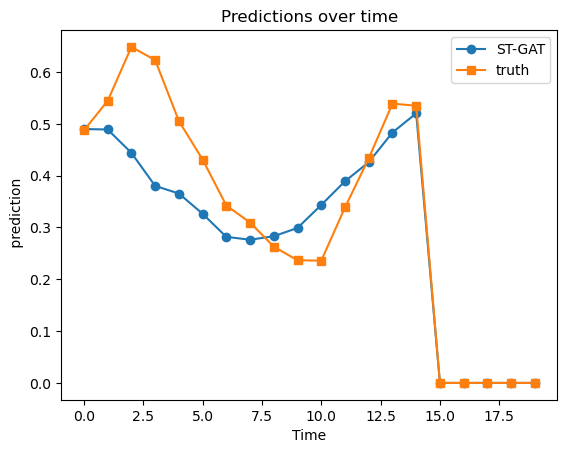

In [12]:
node=100
model_test(model, test_dataloader, device, node,config)

In [ ]:
test_dataloader.dataset[0]

In [ ]:
test_dataloader.dataset[0].x

In [ ]:
test_dataloader.dataset[0].y